In [57]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
from scipy import stats
import matplotlib.colors as mcolors

from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
import cartopy.feature as cfeature







from pylab import rcParams
rcParams['axes.labelweight'] = 'normal'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'normal'

In [58]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


# Define constants
p0 = 1000  # reference pressure in hPa
R = 287.05  # specific gas constant for dry air in J/(kg*K)
cp = 1005  # specific heat at constant pressure for dry air in J/(kg*K)

def convert_to_potential_temperature(T, p):
    """
    Convert temperature to potential temperature.
    
    Parameters:
    T (xarray.DataArray): Temperature in K
    p (xarray.DataArray): Pressure in hPa
    
    Returns:
    xarray.DataArray: Potential temperature in K
    """
    return T * (p0 / p) ** (R / cp)


## SST Trend

In [59]:
# Define the function to compute linear trend (slope only)
def compute_slope(y, x):
    mask = np.isfinite(y)
    if mask.sum() < 2:  # not enough data points
        return np.nan
    return np.polyfit(x[mask], y[mask], 1)[0]  # return slope
def pattern_correlation(da1, da2):
    # Flatten and mask NaNs (shared mask)
    valid = np.isfinite(da1) & np.isfinite(da2)
    return np.corrcoef(da1.values[valid], da2.values[valid])[0, 1]
def weighted_pattern_correlation(da1, da2, weights):
    valid = np.isfinite(da1) & np.isfinite(da2)
    w = weights.broadcast_like(da1)
    w = w.where(valid)

    x = da1.where(valid)
    y = da2.where(valid)

    # Weighted covariance and variance
    x_mean = (x * w).sum() / w.sum()
    y_mean = (y * w).sum() / w.sum()
    
    cov = ((x - x_mean) * (y - y_mean) * w).sum() / w.sum()
    std_x = np.sqrt(((x - x_mean)**2 * w).sum() / w.sum())
    std_y = np.sqrt(((y - y_mean)**2 * w).sum() / w.sum())
    
    return (cov / (std_x * std_y)).item()

# Define a function that returns slope, r², p-value
def linregress_stats(y, x):
    mask = np.isfinite(y)
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan
    res = linregress(x[mask], y[mask])
    return res.slope, res.rvalue**2, res.pvalue

In [60]:
## same but with restricted (45-45)
def pattern_correlation(da1, da2):
    # Restrict to latitude between -45 and 45
    da1 = da1.sel(lat=slice(45, -45))
    da2 = da2.sel(lat=slice(45, -45))
    
    # Flatten and mask NaNs (shared mask)
    valid = np.isfinite(da1) & np.isfinite(da2)
    return np.corrcoef(da1.values[valid], da2.values[valid])[0, 1]
def weighted_pattern_correlation(da1, da2, weights):
    # Restrict to latitude between -45 and 45
    da1 = da1.sel(lat=slice(45, -45))
    da2 = da2.sel(lat=slice(45, -45))
    weights = weights.sel(lat=slice(45, -45))
    
    valid = np.isfinite(da1) & np.isfinite(da2)
    w = weights.broadcast_like(da1)
    w = w.where(valid)

    x = da1.where(valid)
    y = da2.where(valid)

    # Weighted means
    x_mean = (x * w).sum() / w.sum()
    y_mean = (y * w).sum() / w.sum()

    # Weighted covariance and standard deviations
    cov = ((x - x_mean) * (y - y_mean) * w).sum() / w.sum()
    std_x = np.sqrt(((x - x_mean)**2 * w).sum() / w.sum())
    std_y = np.sqrt(((y - y_mean)**2 * w).sum() / w.sum())

    return (cov / (std_x * std_y)).item()


In [61]:


#import sst full data for residual plotting
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst_full = decode_time(fp).sel(lat = slice(90,-90), time = slice('1979', '2023'))

sst_full_aso = sst_full.where(sst_full.time.dt.month.isin([4,5,6,7,8,9])).groupby('time.year').mean()

ds = sst_full_aso.sel(year = slice(1979, 2020))
years = ds.year.values

In [62]:
# Apply across the "year" dimension
results = xr.apply_ufunc(
    linregress_stats,
    ds.sst,
    years,
    input_core_dims=[["year"], ['year']],
    output_core_dims=[[], [], []],
    vectorize=True,
    dask="parallelized",  # Optional, depending on data size
    output_dtypes=[float, float, float]
)

# Unpack results
slope_map, r2_map, pval_map = results

# Label and organize
slope_map = slope_map.rename("slope")
r2_map = r2_map.rename("r_squared")
pval_map = pval_map.rename("p_value")

In [63]:
slope_da = slope_map.copy()
slope_da = slope_da - slope_da.mean(dim = 'lon')
slope_da = slope_da*10


In [64]:
# Apply along 'year' dimension
trend = xr.apply_ufunc(
    compute_slope,
    ds.sst,
    years, 
    input_core_dims=[["year"], ['year']],
    vectorize=True,
    dask="parallelized",  # optional, useful for large datasets
    output_dtypes=[float]
)

In [65]:
# Save as a new dataset if you want

trend_da = trend.rename("sst_trend")
#sutract mean: 
trend_da = trend_da -trend_da.mean(dim = 'lon')
#convert to K/decade
trend_da = trend_da*10

## Add correlation with PDF


In [66]:
corr = xr.open_dataarray('/home/jmex/Python_Notebooks/WRAP/Final_Figures/output/data/corr.nc')
pval = xr.open_dataarray('/home/jmex/Python_Notebooks/WRAP/Final_Figures/output/data/pval.nc')


In [67]:
pdv = -xr.open_dataset('/data/jmex/reg_sst_IPV_ERSSTv5_ERSST5_1900_2014_ANN.nc')

In [68]:
# interpolate trend_da and corr onto ipcc pattern
# Extract the target grid from the reference DataArray
target_lat = pdv.rc['lat']
target_lon = pdv.rc['lon']

# Interpolate 'corr' and 'trend_da' onto the target grid
corr_interp = corr.interp(lat=target_lat, lon=target_lon, method="linear")
pval_interp = pval.interp(lat=target_lat, lon=target_lon, method="linear")

slope_da_interp = slope_da.interp(lat=target_lat, lon=target_lon, method="linear")
pval_map_interp = pval_map.interp(lat=target_lat, lon=target_lon, method="linear")

In [69]:
weights = np.cos(np.deg2rad(pdv.rc.lat))


In [70]:
weighted_pattern_correlation(pdv.rc, corr_interp, weights = weights)

0.4209318815963896

In [71]:
weights = np.cos(np.deg2rad(slope_da_interp.lat))
weighted_pattern_correlation(slope_da_interp, corr_interp, weights = weights)

0.16968581175765576

/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1508: UserWarning: The following kwargs were not used by contour: 'linewidth'
  result = matplotlib.axes.Axes.contourf(self, *args, **kwargs)
/tmp/ipykernel_2689962/3047345684.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


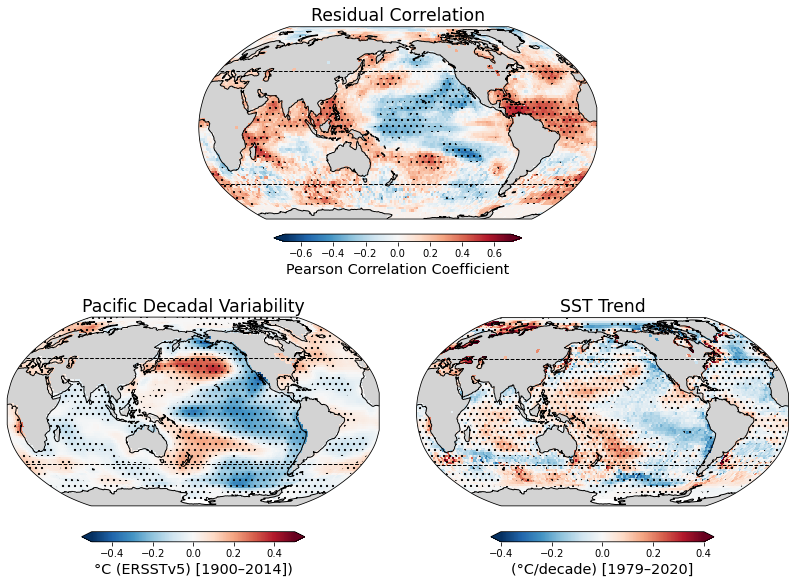

In [73]:
import matplotlib.gridspec as gridspec

# Projection
projection = ccrs.Robinson(central_longitude=180)

# Create figure
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2], hspace=0.3, wspace=0.1)

# Define projections
proj = {'projection': projection}

# Top center plot (Residual Correlation) — span both columns
ax0 = fig.add_subplot(gs[0, :], **proj)

# Bottom left (PDV)
ax1 = fig.add_subplot(gs[1, 0], **proj)

# Bottom right (Trend)
ax2 = fig.add_subplot(gs[1, 1], **proj)


# Compute pattern correlations
pcc_trend_corr = pattern_correlation(slope_da_interp, corr_interp)
pcc_pdv_corr = pattern_correlation(pdv.rc, corr_interp)

# Projection
projection = ccrs.Robinson(central_longitude=180)


# --- 1. Residual Correlation ---
ax = ax0
cbar = ax.pcolormesh(corr_interp.lon, corr_interp.lat, corr_interp, cmap='RdBu_r',
                     transform=ccrs.PlateCarree(), shading='auto', vmin=-0.7, vmax=0.7)
cb = fig.colorbar(cbar, ax=ax0, orientation='horizontal', fraction=0.035, pad=0.07, aspect=30, extend='both')
cb.set_label('Pearson Correlation Coefficient')

# Significance masking
sig_mask = pval_interp < 0.1
ax.contourf(corr_interp.lon, corr_interp.lat, sig_mask, levels=[0.5, 1.5],
            hatches=['..'], colors='none', transform=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')
ax.set_title('Residual Correlation')
ax.set_xticks([])
ax.set_yticks([])

# --- 2. Trend Pattern ---
ax = ax2
tbar = ax.pcolormesh(slope_da_interp.lon, slope_da_interp.lat, slope_da_interp, cmap='RdBu_r',
                     transform=ccrs.PlateCarree(), shading='auto', vmin=-0.4, vmax=0.4)
tb = plt.colorbar(tbar, ax=ax, orientation='horizontal', shrink=0.6, pad=0.1, extend='both')
tb.set_label('(°C/decade) [1979–2020]')

# Significance masking
sig_mask = pval_map_interp < 0.1
ax.contourf(slope_da_interp.lon, slope_da_interp.lat, sig_mask, levels=[0.5, 1.5],
            hatches=['..'], colors='none', transform=ccrs.PlateCarree())


# Draw ±45° latitude lines
ax.plot([0, 360], [45, 45], transform=ccrs.PlateCarree(), color='black', linestyle='--', linewidth=1)
ax.plot([0, 360], [-45, -45], transform=ccrs.PlateCarree(), color='black', linestyle='--', linewidth=1)


ax.coastlines()
ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')
ax.set_title(f'SST Trend')
ax.set_xticks([])
ax.set_yticks([])

# --- 3. PDV Pattern ---
ax = ax1
pbar = ax.pcolormesh(pdv.rc.lon, pdv.rc.lat, pdv.rc, cmap='RdBu_r',
                     transform=ccrs.PlateCarree(), shading='auto', vmin=-0.5, vmax=0.5)
pb = plt.colorbar(pbar, ax=ax, orientation='horizontal', shrink=0.6, pad=0.1, extend='both')
pb.set_label('°C (ERSSTv5) [1900–2014])')

# Significance masking
sig_mask = -pdv.prob_rtest<0.1
ax.contourf(pdv.lon, pdv.lat, sig_mask, levels=[0.5, 1.5],
            hatches=['..'], colors='none', linewidth = 0.3, transform=ccrs.PlateCarree())


ax.coastlines()
ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')
ax.set_title(f'Pacific Decadal Variability')
ax.set_xticks([])
ax.set_yticks([])

# Final layout
for ax in [ax0, ax1, ax2]: 
    # Get full longitude range from the data
    lon_min = ax.get_extent(crs=ccrs.PlateCarree())[0]
    lon_max = ax.get_extent(crs=ccrs.PlateCarree())[1]
    lons = np.linspace(lon_min, lon_max, 100)

    # Add ±45° horizontal lines
    ax.plot(lons, np.full_like(lons, 45), transform=ccrs.PlateCarree(),
            color='black', linestyle='--', linewidth=1, zorder=5)
    ax.plot(lons, np.full_like(lons, -45), transform=ccrs.PlateCarree(),
            color='black', linestyle='--', linewidth=1, zorder=5)


plt.tight_layout()
plt.show()
fig.savefig('output/FigS7_final.png', dpi = 600)


